# 01 — League-Wide Exploratory Data Analysis
---
A systematic exploration of every table in the NHL database.
Uses the `DataProfiler` class from `utils/profiler.py` to run consistent
quality checks across all tables, then digs into cross-table questions
that set up the advanced query and ML work ahead.

**Sections:**
1. Environment setup
2. Database inventory
3. Table profiles (one per table)
4. Cross-table analysis — seasons, teams, players
5. `game_plays` deep dive — shot location coverage for xG model
6. Key findings summary
---

## 1. Environment Setup

In [22]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from config import DB_PATH
from utils.db_connection import run_query, list_tables, table_info
from utils.profiler import DataProfiler

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
print('Ready.')

Ready.


---
## 2. Database Inventory
Quick look at what tables exist and their row counts.

In [23]:
tables = list_tables()
print(f'Tables in NHL_data.db ({len(tables)} total):\n')
print(f'  {"Table":<30} {"Rows":>12}  {"Columns":>8}')
print('  ' + '-' * 54)
for t in tables:
    count = run_query(f'SELECT COUNT(*) as n FROM {t}')["n"].iloc[0]
    cols  = len(table_info(t))
    print(f'  {t:<30} {count:>12,}  {cols:>8}')

Tables in NHL_data.db (10 total):

  Table                                  Rows   Columns
  ------------------------------------------------------
  game                                 26,305        15
  game_goals                          148,992         4
  game_penalties                      247,828         3
  game_plays                        4,116,425        15
  game_plays_players                7,586,604         4
  game_shifts                      11,882,735         5
  game_skater_stats                   945,830        22
  game_teams_stats                     52,610        17
  player_info                           3,925        12
  team_info                                33         6


---
## 3. Table Profiles
Each table gets a full `DataProfiler.summary()` pass.
We load smaller tables in full and sample larger ones to keep things fast.

In [24]:
# ── game ──────────────────────────────────────────────────────
df_game = run_query('SELECT * FROM game')
DataProfiler(df_game, name='game').summary()


  [ game ]  PROFILE SUMMARY

  Rows   : 26,305
  Columns: 15

  [ game ]  COLUMN TYPES
  {dtype('O'): np.int64(8), dtype('int64'): np.int64(7)}

game_id                    int64
season                     int64
type                      object
date_time_GMT             object
away_team_id               int64
home_team_id               int64
away_goals                 int64
home_goals                 int64
outcome                   object
home_rink_side_start      object
venue                     object
venue_link                object
venue_time_zone_id        object
venue_time_zone_offset     int64
venue_time_zone_tz        object

  [ game ]  NULL REPORT
  1 column(s) with nulls:

                      null_count  null_pct
home_rink_side_start        1196      4.55

  Total null cells: 1,196 / 394,575 (0.30%)

  [ game ]  DUPLICATE REPORT
  2,570 duplicate row(s) found (all columns).
  Sample duplicates:
          game_id    season type         date_time_GMT  away_team_id  home_team

In [25]:
# ── team_info ─────────────────────────────────────────────────
df_teams = run_query('SELECT * FROM team_info')
DataProfiler(df_teams, name='team_info').summary()


  [ team_info ]  PROFILE SUMMARY

  Rows   : 33
  Columns: 6

  [ team_info ]  COLUMN TYPES
  {dtype('O'): np.int64(4), dtype('int64'): np.int64(2)}

team_id          int64
franchiseId      int64
shortName       object
teamName        object
abbreviation    object
link            object

  [ team_info ]  NULL REPORT
  No nulls found.

  Total null cells: 0 / 198 (0.00%)

  [ team_info ]  DUPLICATE REPORT
  No duplicate rows found (all columns).

  [ team_info ]  NUMERIC RANGES
             min   max  mean   std
team_id     1.00 54.00 18.91 13.79
franchiseId 1.00 38.00 22.97 10.04


In [26]:
# ── player_info ───────────────────────────────────────────────
df_players = run_query('SELECT * FROM player_info')
DataProfiler(df_players, name='player_info').summary()


  [ player_info ]  PROFILE SUMMARY

  Rows   : 3,925
  Columns: 12

  [ player_info ]  COLUMN TYPES
  {dtype('O'): np.int64(9), dtype('float64'): np.int64(2), dtype('int64'): np.int64(1)}

player_id               int64
firstName              object
lastName               object
nationality            object
birthCity              object
primaryPosition        object
birthDate              object
birthStateProvince     object
height                 object
height_cm             float64
weight                float64
shootsCatches          object

  [ player_info ]  NULL REPORT
  7 column(s) with nulls:

                    null_count  null_pct
nationality                  8      0.20
birthCity                    5      0.13
birthStateProvince        1123     28.61
height                       3      0.08
height_cm                    3      0.08
weight                       3      0.08
shootsCatches               17      0.43

  Total null cells: 1,162 / 47,100 (2.47%)

  [ player_info ] 

In [27]:
# ── game_skater_stats ─────────────────────────────────────────
df_skaters = run_query('SELECT * FROM game_skater_stats')
DataProfiler(df_skaters, name='game_skater_stats').summary()


  [ game_skater_stats ]  PROFILE SUMMARY

  Rows   : 945,830
  Columns: 22

  [ game_skater_stats ]  COLUMN TYPES
  {dtype('int64'): np.int64(18), dtype('float64'): np.int64(4)}

game_id                   int64
player_id                 int64
team_id                   int64
timeOnIce                 int64
assists                   int64
goals                     int64
shots                     int64
hits                    float64
powerPlayGoals            int64
powerPlayAssists          int64
penaltyMinutes            int64
faceOffWins               int64
faceoffTaken              int64
takeaways               float64
giveaways               float64
shortHandedGoals          int64
shortHandedAssists        int64
blocked                 float64
plusMinus                 int64
evenTimeOnIce             int64
shortHandedTimeOnIce      int64
powerPlayTimeOnIce        int64

  [ game_skater_stats ]  NULL REPORT
  4 column(s) with nulls:

           null_count  null_pct
hits           3981

In [28]:
# ── game_teams_stats ─────────────────────────────────────────
df_team_stats = run_query('SELECT * FROM game_teams_stats')
DataProfiler(df_team_stats, name='game_teams_stats').summary()


  [ game_teams_stats ]  PROFILE SUMMARY

  Rows   : 52,610
  Columns: 17

  [ game_teams_stats ]  COLUMN TYPES
  {dtype('float64'): np.int64(10), dtype('O'): np.int64(4), dtype('int64'): np.int64(3)}

game_id                     int64
team_id                     int64
HoA                        object
won                         int64
settled_in                 object
head_coach                 object
goals                     float64
shots                     float64
hits                      float64
pim                       float64
powerPlayOpportunities    float64
powerPlayGoals            float64
faceOffWinPercentage      float64
giveaways                 float64
takeaways                 float64
blocked                   float64
startRinkSide              object

  [ game_teams_stats ]  NULL REPORT
  12 column(s) with nulls:

                        null_count  null_pct
head_coach                      28      0.05
goals                            8      0.02
shots               

In [29]:
# ── game_goals ────────────────────────────────────────────────
df_goals = run_query('SELECT * FROM game_goals')
DataProfiler(df_goals, name='game_goals').summary()


  [ game_goals ]  PROFILE SUMMARY

  Rows   : 148,992
  Columns: 4

  [ game_goals ]  COLUMN TYPES
  {dtype('O'): np.int64(2), dtype('float64'): np.int64(2)}

play_id             object
strength            object
gameWinningGoal    float64
emptyNet           float64

  [ game_goals ]  NULL REPORT
  2 column(s) with nulls:

                 null_count  null_pct
gameWinningGoal        1844      1.24
emptyNet               5043      3.38

  Total null cells: 6,887 / 595,968 (1.16%)

  [ game_goals ]  DUPLICATE REPORT
  15,647 duplicate row(s) found (all columns).
  Sample duplicates:
               play_id strength  gameWinningGoal  emptyNet
117670    2019020001_5     Even             0.00      0.00
117671  2019020001_146     Even             0.00      0.00
117672  2019020001_166     Even             0.00      0.00
117673  2019020001_173     Even             0.00      0.00

  [ game_goals ]  NUMERIC RANGES
                 min  max  mean  std
gameWinningGoal 0.00 1.00  0.16 0.37
emptyNet

In [30]:
# ── game_penalties ────────────────────────────────────────────
df_penalties = run_query('SELECT * FROM game_penalties')
DataProfiler(df_penalties, name='game_penalties').summary()


  [ game_penalties ]  PROFILE SUMMARY

  Rows   : 247,828
  Columns: 3

  [ game_penalties ]  COLUMN TYPES
  {dtype('O'): np.int64(2), dtype('int64'): np.int64(1)}

play_id            object
penaltySeverity    object
penaltyMinutes      int64

  [ game_penalties ]  NULL REPORT
  1 column(s) with nulls:

                 null_count  null_pct
penaltySeverity      127529     51.46

  Total null cells: 127,529 / 743,484 (17.15%)

  [ game_penalties ]  DUPLICATE REPORT
  18,600 duplicate row(s) found (all columns).
  Sample duplicates:
               play_id penaltySeverity  penaltyMinutes
210570   2019020001_10           Minor               2
210571   2019020001_34           Minor               2
210572   2019020001_50           Minor               2
210573  2019020001_195           Minor               2

  [ game_penalties ]  NUMERIC RANGES
                min   max  mean  std
penaltyMinutes 0.00 10.00  2.45 1.46


In [31]:
# ── game_shifts (large — sample 50k rows for profiling) ───────
df_shifts = run_query('SELECT * FROM game_shifts LIMIT 50000')
p = DataProfiler(df_shifts, name='game_shifts (50k sample)')
p.summary()
print('\nNote: Full table not loaded. Row count from inventory cell above.')


  [ game_shifts (50k sample) ]  PROFILE SUMMARY

  Rows   : 50,000
  Columns: 5

  [ game_shifts (50k sample) ]  COLUMN TYPES
  {dtype('int64'): np.int64(4), dtype('float64'): np.int64(1)}

game_id          int64
player_id        int64
period           int64
shift_start      int64
shift_end      float64

  [ game_shifts (50k sample) ]  NULL REPORT
  No nulls found.

  Total null cells: 0 / 250,000 (0.00%)

  [ game_shifts (50k sample) ]  DUPLICATE REPORT
  24,618 duplicate row(s) found (all columns).
  Sample duplicates:
      game_id  player_id  period  shift_start  shift_end
0  2018020001    8466139       1            0      42.00
1  2018020001    8466139       1          207     247.00
2  2018020001    8466139       1          375     413.00
3  2018020001    8466139       1          556     574.00

  [ game_shifts (50k sample) ]  NUMERIC RANGES
                         min              max             mean      std
game_id     2,018,020,001.00 2,018,020,033.00 2,018,020,016.26     

In [32]:
# ── game_plays_players ────────────────────────────────────────
df_pp = run_query('SELECT * FROM game_plays_players LIMIT 50000')
DataProfiler(df_pp, name='game_plays_players (50k sample)').summary()


  [ game_plays_players (50k sample) ]  PROFILE SUMMARY

  Rows   : 50,000
  Columns: 4

  [ game_plays_players (50k sample) ]  COLUMN TYPES
  {dtype('O'): np.int64(2), dtype('int64'): np.int64(2)}

play_id       object
game_id        int64
player_id      int64
playerType    object

  [ game_plays_players (50k sample) ]  NULL REPORT
  No nulls found.

  Total null cells: 0 / 200,000 (0.00%)

  [ game_plays_players (50k sample) ]  DUPLICATE REPORT
  No duplicate rows found (all columns).

  [ game_plays_players (50k sample) ]  NUMERIC RANGES
                       min              max             mean        std
game_id   2,015,020,007.00 2,017,021,257.00 2,016,153,924.26 808,355.66
player_id     8,448,208.00     8,480,382.00     8,474,296.27   3,064.74


---
## 4. Cross-Table Analysis
Big picture questions about the scope and shape of the full dataset.

In [33]:
# Seasons and game type breakdown
seasons = run_query("""
    SELECT season,
           type,
           COUNT(*) as games,
           COUNT(DISTINCT home_team_id) as teams
    FROM game
    GROUP BY season, type
    ORDER BY season, type
""")
print('Seasons in database:\n')
print(seasons.to_string(index=False))

Seasons in database:

  season type  games  teams
20002001    R   1230     30
20012002    R   1230     30
20022003    R   1230     30
20032004    R   1230     30
20052006    R   1230     30
20062007    R   1230     30
20072008    R   1230     30
20082009    R   1230     30
20092010    R   1230     30
20102011    P     89     16
20102011    R   1230     30
20112012    P     86     16
20112012    R   1230     30
20122013    P     86     16
20122013    R    720     30
20132014    P     93     16
20132014    R   1230     30
20142015    P     89     16
20142015    R   1230     30
20152016    P     91     16
20152016    R   1230     30
20162017    P     93     16
20162017    R   1230     30
20172018    P     92     16
20172018    R   1271     31
20182019    A      4      2
20182019    P    174     16
20182019    R   2542     31
20192020    A      6      3
20192020    P    231     24
20192020    R   2188     31


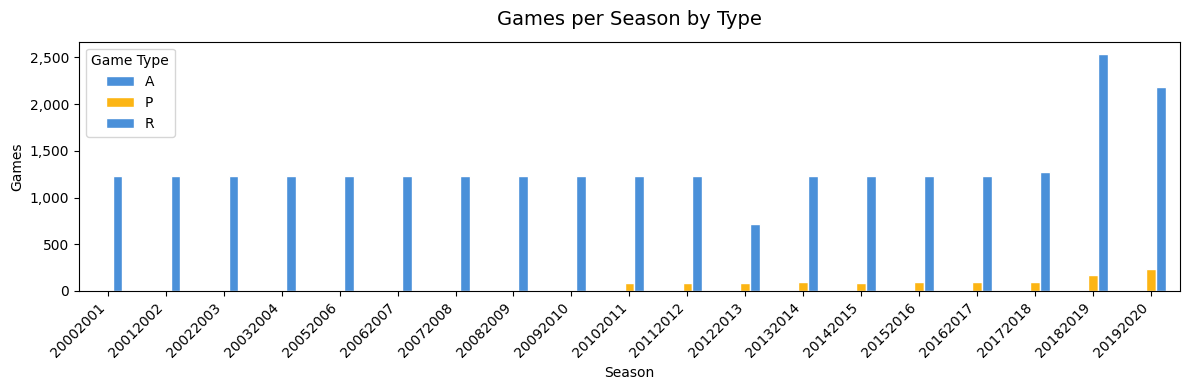

In [34]:
# Games per season chart — regular season vs playoffs
pivot = seasons.pivot(index='season', columns='type', values='games').fillna(0)
pivot.index = pivot.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
pivot.plot(kind='bar', ax=ax, color=['#4a90d9', '#FCB514'], edgecolor='white')
ax.set_title('Games per Season by Type', fontsize=14, pad=12)
ax.set_xlabel('Season')
ax.set_ylabel('Games')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Game Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
# Most represented players in the skater stats (career game count)
top_players = run_query("""
    SELECT p.firstName || ' ' || p.lastName as player,
           p.primaryPosition as position,
           COUNT(DISTINCT s.game_id) as games,
           ROUND(SUM(s.goals) * 1.0, 0) as total_goals,
           ROUND(SUM(s.assists) * 1.0, 0) as total_assists
    FROM game_skater_stats s
    JOIN player_info p ON s.player_id = p.player_id
    GROUP BY s.player_id
    ORDER BY games DESC
    LIMIT 20
""")
print('Top 20 players by games in the database:\n')
print(top_players.to_string(index=False))

Top 20 players by games in the database:

          player position  games  total_goals  total_assists
 Patrick Marleau        C   1576       565.00         619.00
     Zdeno Chara        D   1523       224.00         491.00
    Joe Thornton        C   1507       421.00       1,140.00
 Justin Williams       RW   1381       389.00         557.00
    Henrik Sedin        C   1370       246.00         858.00
     Matt Cullen        C   1369       251.00         431.00
    Daniel Sedin       LW   1343       404.00         666.00
 Jay Bouwmeester        D   1315        92.00         378.00
  Scott Hartnell       LW   1286       331.00         391.00
   Jarome Iginla       RW   1270       543.00         580.00
    Dustin Brown       RW   1262       356.00         425.00
   Alex Ovechkin       LW   1260       862.00         677.00
      Eric Staal        C   1259       480.00         653.00
    Marian Hossa       RW   1249       499.00         606.00
    Duncan Keith        D   1234       126.

In [36]:
# Confirm all 30/31 NHL teams are present
teams = run_query("""
    SELECT t.team_id, t.abbreviation, t.teamName,
           COUNT(DISTINCT g.game_id) as games_played
    FROM team_info t
    LEFT JOIN game g ON g.home_team_id = t.team_id
                     OR g.away_team_id = t.team_id
    GROUP BY t.team_id
    ORDER BY games_played DESC
""")
print(f'Teams in database: {len(teams)}\n')
print(teams.to_string(index=False))

Teams in database: 33

 team_id abbreviation       teamName  games_played
       6          BOS         Bruins          1633
       5          PIT       Penguins          1628
      15          WSH       Capitals          1623
      14          TBL      Lightning          1623
      28          SJS         Sharks          1615
       3          NYR        Rangers          1614
      16          CHI     Blackhawks          1611
      19          STL          Blues          1606
      18          NSH      Predators          1601
      26          LAK          Kings          1592
      24          ANA          Ducks          1586
      25          DAL          Stars          1570
       8          MTL      Canadiens          1570
      23          VAN        Canucks          1568
       4          PHI         Flyers          1568
       2          NYI      Islanders          1564
      17          DET      Red Wings          1560
      30          MIN           Wild          1559
       9

---
## 5. `game_plays` Deep Dive
This table powers the Expected Goals (xG) model. We need to confirm
x/y coordinate coverage is good enough to build on.

In [37]:
# Event type distribution
events = run_query("""
    SELECT event,
           COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM game_plays), 2) as pct
    FROM game_plays
    GROUP BY event
    ORDER BY count DESC
""")
print('Event types in game_plays:\n')
print(events.to_string(index=False))

Event types in game_plays:

       event  count   pct
     Faceoff 894041 21.72
        Shot 845164 20.53
         Hit 706096 17.15
Blocked Shot 431922 10.49
 Missed Shot 357214  8.68
    Giveaway 273287  6.64
     Penalty 247828  6.02
    Takeaway 211881  5.15
        Goal 148992  3.62


In [38]:
# x/y coordinate coverage for shots and goals (critical for xG)
coord_coverage = run_query("""
    SELECT event,
           COUNT(*) as total,
           SUM(CASE WHEN x IS NOT NULL AND y IS NOT NULL THEN 1 ELSE 0 END) as has_coords,
           ROUND(
               SUM(CASE WHEN x IS NOT NULL AND y IS NOT NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
               2
           ) as coord_pct
    FROM game_plays
    WHERE event IN ('Shot', 'Goal', 'Missed Shot', 'Blocked Shot')
    GROUP BY event
    ORDER BY total DESC
""")
print('Coordinate coverage for shot events (critical for xG model):\n')
print(coord_coverage.to_string(index=False))

Coordinate coverage for shot events (critical for xG model):

       event  total  has_coords  coord_pct
        Shot 845164      842258      99.66
Blocked Shot 431922      431913     100.00
 Missed Shot 357214      356283      99.74
        Goal 148992       87252      58.56


In [39]:
# Shot type breakdown (Wrist, Slap, Snap, Backhand, etc.)
shot_types = run_query("""
    SELECT secondaryType as shot_type,
           COUNT(*) as count
    FROM game_plays
    WHERE event = 'Shot'
    GROUP BY secondaryType
    ORDER BY count DESC
""")
print('Shot types:\n')
print(shot_types.to_string(index=False))

Shot types:

  shot_type  count
 Wrist Shot 444628
  Slap Shot 153602
  Snap Shot 119783
   Backhand  68599
     Tip-In  36697
  Deflected  12103
Wrap-around   9722
       None     30


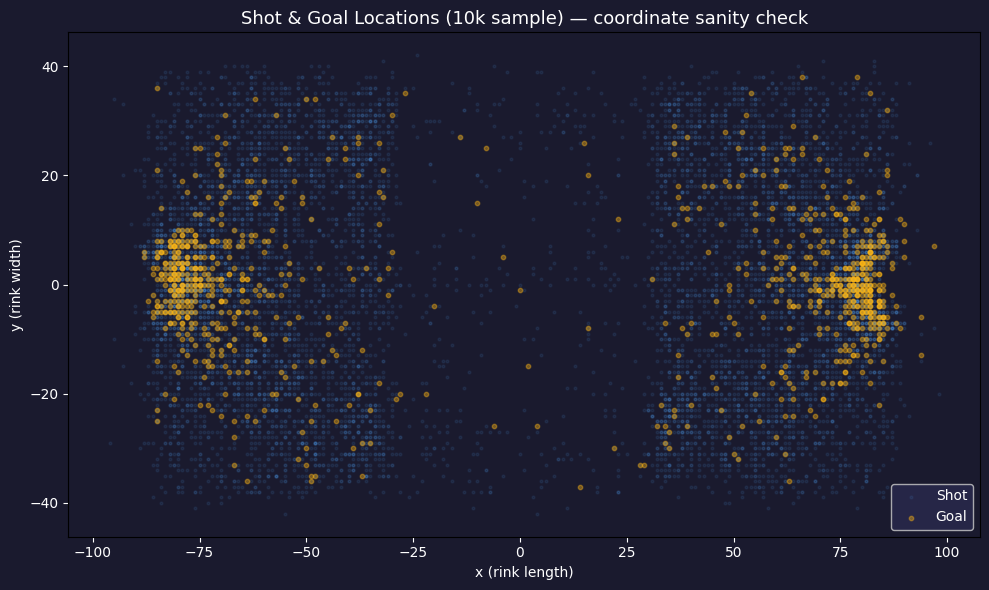

In [40]:
# Shot location scatter — quick visual to confirm coordinates make sense
shots_sample = run_query("""
    SELECT x, y, event
    FROM game_plays
    WHERE event IN ('Shot', 'Goal')
      AND x IS NOT NULL
      AND y IS NOT NULL
    LIMIT 10000
""")

fig, ax = plt.subplots(figsize=(10, 6))
goals = shots_sample[shots_sample['event'] == 'Goal']
shots = shots_sample[shots_sample['event'] == 'Shot']

ax.scatter(shots['x'], shots['y'], alpha=0.1, s=4, color='#4a90d9', label='Shot')
ax.scatter(goals['x'], goals['y'], alpha=0.4, s=10, color='#FCB514', label='Goal')

ax.set_title('Shot & Goal Locations (10k sample) — coordinate sanity check', fontsize=13)
ax.set_xlabel('x (rink length)')
ax.set_ylabel('y (rink width)')
ax.legend()
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.legend(facecolor='#2a2a4e', labelcolor='white')
plt.tight_layout()
plt.show()

---
## 6. Data Cleaning — Deduplication

### What we found
The profiler flagged duplicate rows across five tables:
`game`, `game_skater_stats`, `game_teams_stats`, `game_goals`, and `game_penalties`.
The sample duplicates all pointed to the same source: game IDs from the
2019-2020 season (e.g. `2019020001`). Cross-referencing with the seasons
inventory confirmed the issue — the 2018-2019 regular season shows **2,542 games**
when an 82-game schedule with 31 teams produces exactly 1,271.
The 2019-2020 season (shortened by COVID) is similarly inflated.
The Kaggle dataset was assembled from two separate data pulls and both recent
seasons were included twice.

### How we fix it
We do **not** modify the raw tables. Instead, we create SQL **views** named
`clean_<table>` that deduplicate on each table's natural primary key using
SQLite's internal `rowid` to keep the first-inserted copy of each duplicate.
This is non-destructive — the raw data is always recoverable — and it means
every downstream query, analysis module, and ML model simply uses `clean_game`
instead of `game`, and so on.

The `clean_game` view also silently filters out **All-Star games** (type `A`),
which have no analytical value for team or player performance work.

### Views created
| Raw Table | Clean View | Deduplicated On |
|---|---|---|
| `game` | `clean_game` | `game_id` (+ filters type \!= 'A') |
| `game_skater_stats` | `clean_game_skater_stats` | `game_id, player_id` |
| `game_teams_stats` | `clean_game_teams_stats` | `game_id, team_id` |
| `game_goals` | `clean_game_goals` | `play_id` |
| `game_penalties` | `clean_game_penalties` | `play_id` |
| `game_plays` | `clean_game_plays` | `play_id` |

In [41]:
from utils.db_connection import create_clean_views, list_views

create_clean_views()

ImportError: cannot import name 'create_clean_views' from 'utils.db_connection' (c:\Users\abonc\OneDrive\Documents\Ailene\Projects\nhl-analytics\utils\db_connection.py)

### Verify: before vs. after row counts
The table below compares raw row counts against the deduplicated view counts,
confirming the duplicate rows have been removed.

In [ ]:
pairs = [
    ('game',               'clean_game'),
    ('game_skater_stats',  'clean_game_skater_stats'),
    ('game_teams_stats',   'clean_game_teams_stats'),
    ('game_goals',         'clean_game_goals'),
    ('game_penalties',     'clean_game_penalties'),
    ('game_plays',         'clean_game_plays'),
]

print(f"{'Raw Table':<30} {'Raw Rows':>12}  {'Clean Rows':>12}  {'Removed':>10}")
print('-' * 70)
for raw, clean in pairs:
    raw_n   = run_query(f'SELECT COUNT(*) as n FROM {raw}')['n'].iloc[0]
    clean_n = run_query(f'SELECT COUNT(*) as n FROM {clean}')['n'].iloc[0]
    removed = raw_n - clean_n
    print(f"  {raw:<28} {raw_n:>12,}  {clean_n:>12,}  {removed:>10,}")

### Verify: season counts look correct after deduplication

In [ ]:
# Re-run the seasons query against clean_game to confirm 2018-2019 and
# 2019-2020 now show the correct game counts
seasons_clean = run_query("""
    SELECT season, type, COUNT(*) as games
    FROM clean_game
    GROUP BY season, type
    ORDER BY season, type
""")
print('Season counts from clean_game (should now be ~1,230-1,271 for regular seasons):\n')
print(seasons_clean.to_string(index=False))

---
## 7. Key Findings Summary

### Data Coverage
- **Seasons:** 2000-01 through 2019-20 (20 seasons). No 2004-05 (lockout — correct).
- **Teams:** 33 entries including historical franchises (Atlanta Thrashers, Phoenix/Arizona Coyotes, Winnipeg Jets v2, Vegas Golden Knights). All 30-31 active teams present.
- **Players:** 3,925 skaters across all seasons.
- **Playoff data:** Available from **2010-11 onwards only**. Regular season data covers all 20 seasons. ML models predicting playoff outcomes will train on 2010-2020 (10 seasons).

### Data Quality
- **Duplicates (fixed):** The 2018-19 and 2019-20 seasons were ingested twice in the source data. Resolved via `clean_*` views — all downstream work uses these.
- **All-Star games filtered:** Type `A` games removed from `clean_game`. No analytical value.
- **`hits`, `takeaways`, `giveaways`, `blocked` — 42% null:** Not a quality issue. These stats were not tracked before approximately 2010. Features using these columns must be limited to seasons where they exist, or handled with null-aware logic in models.
- **`faceOffWinPercentage` — 42% null in `game_teams_stats`:** Same reason as above.
- **`penaltySeverity` — 51% null in `game_penalties`:** Certain penalty categories do not receive a severity classification. Use `penaltyMinutes` as the primary penalty signal; treat severity as a supplementary feature only.
- **`birthStateProvince` — 29% null in `player_info`:** Expected. International players have no state/province. Not a data quality issue.
- **`home_rink_side_start` — 4.5% null in `game`:** Minor. Only relevant if modeling home/away dynamics by rink end — can be excluded from features.

### xG Model Readiness
- **Shot coordinate coverage: 99.66%** — excellent foundation for Expected Goals.
- **Goal coordinate coverage: 58.56%** — goals as a play event type have poor coordinate data. Strategy: build xG on **shots** (not goals), join goals to their originating shot via `play_id` when location is needed for goal events.
- **Shot types available:** Wrist Shot, Slap Shot, Snap Shot, Backhand, Tip-In, Deflected, Wrap-around — all major types present.

### Rules for All Downstream Work
1. **Always query `clean_*` views, never raw tables** for the six affected tables.
2. **Always filter `type \!= 'A'`** in any query touching the `game` table directly (already baked into `clean_game`).
3. **Know your null boundary:** analyses using hits/takeaways/giveaways/blocked are valid from ~2010-11 onwards only.
4. **Playoff ML training window:** 2010-11 to 2019-20 (10 playoff seasons).